# Disease Prediction and Recommendation System using Machine Learning

**Overview**

This notebook presents the development of a machine learning-based disease prediction system that analyzes patient symptoms to predict diseases and generate appropriate recommendations, including medications, diets, workouts, and precautionary measures.

The following approaches will be taken:

* Problem definition

* Data

* Evaluation

* Features

* Modelling

* Experimentation

## 1. Problem Definition

> How well can I predict diseases given patients' symptom data and recommend appropriate medications, diets, workouts, and precautionary measures?

## 2. Data

This version of data was found in:  https://www.kaggle.com/datasets/noorsaeed/medicine-recommendation-system-dataset

There are eight datasets:

* description.csv - Provides disease names with corresponding definitions and details.
* diets.csv - Contains diet recommendations for the diseases.
* precautions_df.csv - – Outlines precautionary measures for each disease. 
* medications.csv - Contains medicine prescribed for various diseases.
* symptom_sevirity.csv- Maps symptoms to its severity score (numerical scale).
* symptoms.csv - Contains various symptoms associated with the diseases.
* training.csv - Training dataset mapping symptoms to diseases for ML model training.
* workout.csv - Suggests lifestyle changes and dietary adjustments.

## 3. Evaluation

The evaluation metrics for this project are: Accuracy, Precision, Recall, F1 score and Confusion matrix.

## 4. Features

The dataset contains several features across different files:

**training.csv**

This is the main dataset for ML model training. It includes:

Symptom1, Symptom2, Symptom3, … → Columns representing patient-reported symptoms.

Disease → Target label mapping symptoms to a specific disease.


**symptom_severity.csv**

Symptom → Name of the symptom.

Weight → Numerical score representing the severity of the symptom.


**description.csv**

Disease → Name of the disease.

Description → Textual details about the disease.


**medications.csv**

Disease → Disease name.

Medication → Recommended medicine.


**diets.csv**

Disease → Disease name.

Diet → Food/diet recommendations.


**workout.csv**

Disease → Disease name.

Workout → Suggested workouts and lifestyle adjustments.


**precautions_df.csv**

Disease → Disease name.

Precaution_1, Precaution_2, Precaution_3, Precaution_4 → Recommended precautions.



**symptoms.csv**

Symptom → Symptom name.

Disease → Associated disease.


## Preparing the tools

In [4]:
import warnings
warnings.filterwarnings('ignore')

# Regular EDA (exploratory data analysis) and plotting libraries
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [5]:
training_df = pd.read_csv("ml/data/processed/train/Training.csv")
diet_df = pd.read_csv("ml/data/processed/diet/diets.csv")
medications_df = pd.read_csv("ml/data/processed/medication/medications.csv")
description_df = pd.read_csv("ml/data/processed/description/description.csv")
precautions_df = pd.read_csv("ml/data/processed/precaution/precautions_df.csv", index_col=[0])
symptoms_df = pd.read_csv("ml/data/processed/symptoms/symtoms_df.csv", index_col=[0])
symptoms_severity_df = pd.read_csv("ml/data/processed/symptom-severity/Symptom-severity.csv")
workout_df = pd.read_csv("ml/data/processed/workout/workout_df.csv", index_col=[0, 1])

## Exploratory Data Analysis (EDA)

In [6]:
training_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [7]:
medications_df.head()

,Disease,Medication
0,Fungal infection,"['Antifungal Cream', 'Fluconazole', 'Terbinafi..."
1,Allergy,"['Antihistamines', 'Decongestants', 'Epinephri..."
2,GERD,"['Proton Pump Inhibitors (PPIs)', 'H2 Blockers..."
3,Chronic cholestasis,"['Ursodeoxycholic acid', 'Cholestyramine', 'Me..."
4,Drug Reaction,"['Antihistamines', 'Epinephrine', 'Corticoster..."


In [8]:
diet_df.head()

,Disease,Diet
0,Fungal infection,"['Antifungal Diet', 'Probiotics', 'Garlic', 'C..."
1,Allergy,"['Elimination Diet', 'Omega-3-rich foods', 'Vi..."
2,GERD,"['Low-Acid Diet', 'Fiber-rich foods', 'Ginger'..."
3,Chronic cholestasis,"['Low-Fat Diet', 'High-Fiber Diet', 'Lean prot..."
4,Drug Reaction,"['Antihistamine Diet', 'Omega-3-rich foods', '..."


In [9]:
description_df.head()

,Disease,Description
0,Fungal infection,Fungal infection is a common skin condition ca...
1,Allergy,Allergy is an immune system reaction to a subs...
2,GERD,GERD (Gastroesophageal Reflux Disease) is a di...
3,Chronic cholestasis,Chronic cholestasis is a condition where bile ...
4,Drug Reaction,Drug Reaction occurs when the body reacts adve...


In [10]:
symptoms_df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN


In [11]:
symptoms_severity_df.head()

,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


In [12]:
precautions_df.head()

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [13]:
workout_df.head()

,,disease,workout
,Unnamed: 0,,
0,0,Fungal infection,Avoid sugary foods
1,1,Fungal infection,Consume probiotics
2,2,Fungal infection,Increase intake of garlic
3,3,Fungal infection,Include yogurt in diet
4,4,Fungal infection,Limit processed foods


In [14]:
workout_df = workout_df.reset_index(drop=True)

In [15]:
workout_df.head()

,disease,workout
0,Fungal infection,Avoid sugary foods
1,Fungal infection,Consume probiotics
2,Fungal infection,Increase intake of garlic
3,Fungal infection,Include yogurt in diet
4,Fungal infection,Limit processed foods


In [16]:
training_df.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
training_df.info(max_cols=134)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 133 columns):
 #    Column                          Non-Null Count  Dtype 
---   ------                          --------------  ----- 
 0    itching                         4920 non-null   int64 
 1    skin_rash                       4920 non-null   int64 
 2    nodal_skin_eruptions            4920 non-null   int64 
 3    continuous_sneezing             4920 non-null   int64 
 4    shivering                       4920 non-null   int64 
 5    chills                          4920 non-null   int64 
 6    joint_pain                      4920 non-null   int64 
 7    stomach_pain                    4920 non-null   int64 
 8    acidity                         4920 non-null   int64 
 9    ulcers_on_tongue                4920 non-null   int64 
 10   muscle_wasting                  4920 non-null   int64 
 11   vomiting                        4920 non-null   int64 
 12   burning_micturition             

In [18]:
training_df.isna().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64

There are no missing values in our training data

### Number of Symptoms per Disease

In [20]:
symptoms_df = symptoms_df.copy()

symptom_cols = [col for col in symptoms_df.columns if col != 'Disease']

symptoms_df['symptom_count'] = (
    symptoms_df[symptom_cols]
    .notna()
    .sum(axis=1)
)

symptoms_per_disease = (
    symptoms_df.groupby('Disease')['symptom_count']
    .sum()
    .reset_index()
)

symptoms_per_disease

,Disease,symptom_count
0,(vertigo) Paroymsal Positional Vertigo,480
1,AIDS,438
2,Acne,438
3,Alcoholic hepatitis,480
4,Allergy,432
5,Arthritis,480
6,Bronchial Asthma,480
7,Cervical spondylosis,480
8,Chicken pox,480
9,Chronic cholestasis,480


### Distribution of Symptoms Severity

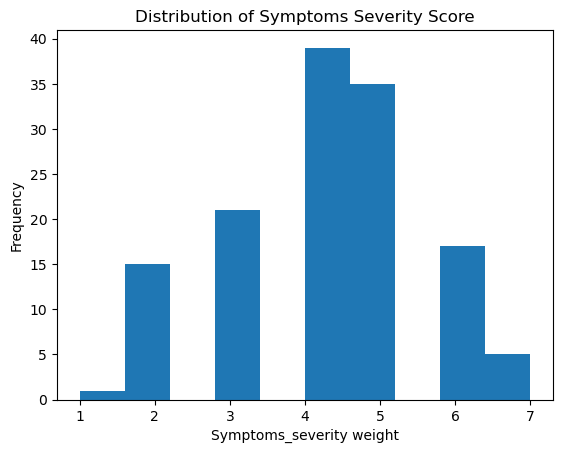

In [21]:
plt.hist(symptoms_severity_df['weight'])

plt.xlabel('Symptoms_severity weight')
plt.ylabel('Frequency')
plt.title('Distribution of Symptoms Severity Score')

plt.show()

### Average severity score across all symptoms

In [22]:
avg_score = symptoms_severity_df.groupby('Symptom')['weight'].mean()

avg_score

Symptom
abdominal_pain           4.0
abnormal_menstruation    6.0
acidity                  3.0
acute_liver_failure      6.0
altered_sensorium        2.0
                        ... 
weight_loss              3.0
yellow_crust_ooze        3.0
yellow_urine             4.0
yellowing_of_eyes        4.0
yellowish_skin           3.0
Name: weight, Length: 132, dtype: float64

> 🔑 **Note:**
>
> 'ast.literal_eval()' is used to convert string representations of Python lists into actual list objects, enabling operations such as 'explode()' for frequency analysis to transform list-like entries into separate rows, enabling individual elements to be analyzed, aggregated, and visualized independently.
>
> Example:
>
> `import ast`
>
>`diet_df['Diet'] = diet_df['Diet'].apply(ast.literal_eval)` 

### Most Prescribed Medications

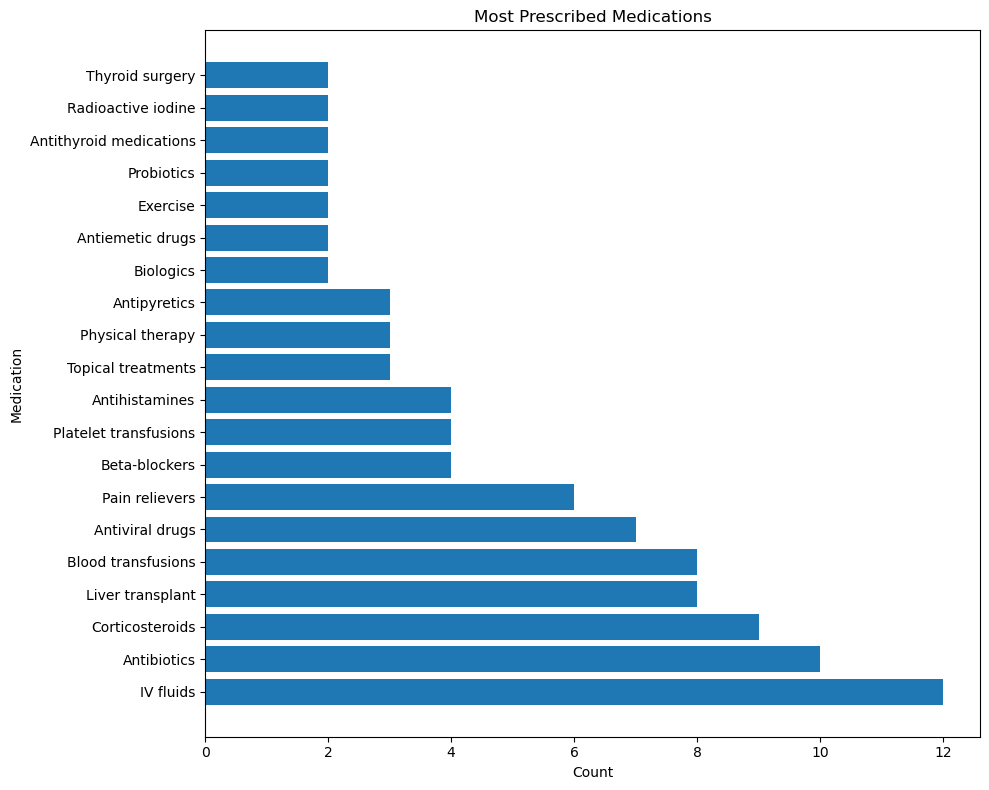

In [23]:
import ast
medications_df['Medication'] = medications_df['Medication'].apply(ast.literal_eval)

medications_exploded = medications_df.explode('Medication')
medications_count = medications_exploded['Medication'].value_counts().head(20)

plt.figure(figsize=(10, 8))
plt.barh(medications_count.index, medications_count.values)
plt.xlabel("Count")
plt.ylabel("Medication")
plt.title("Most Prescribed Medications")
plt.tight_layout()
plt.show()

### Most Recommended Workouts

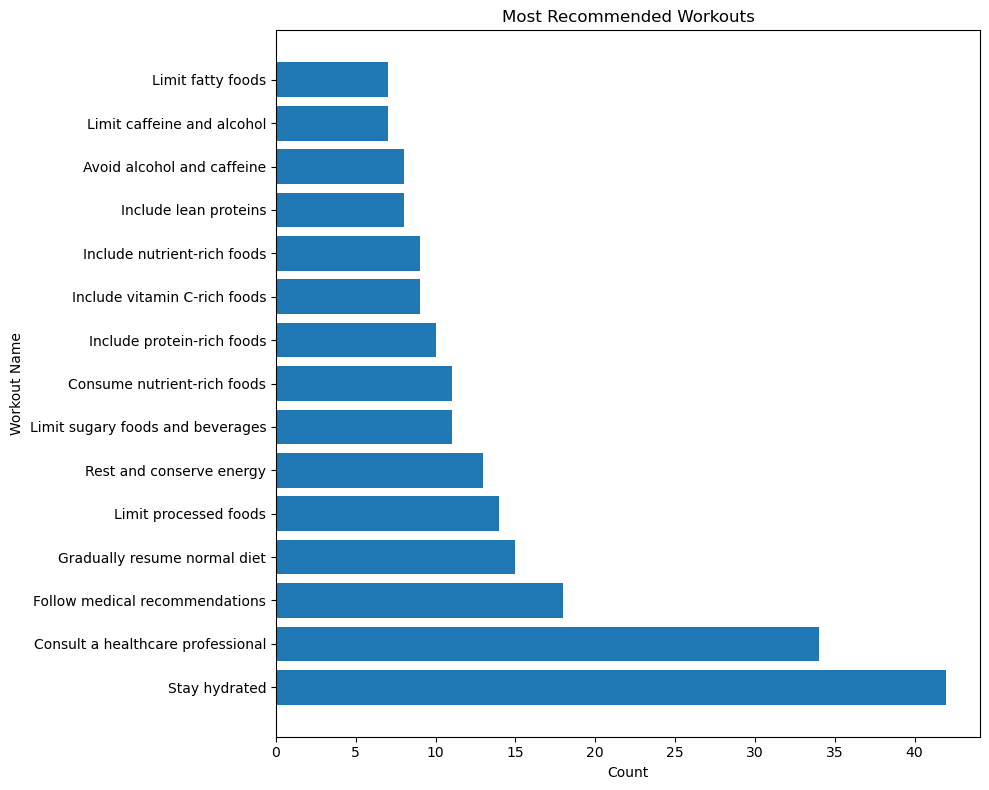

In [24]:
workout_count = workout_df["workout"].value_counts().head(15)
plt.figure(figsize=(10, 8))
plt.barh(workout_count.index, workout_count)
plt.xlabel("Count")
plt.ylabel("Workout Name")
plt.title("Most Recommended Workouts")
plt.tight_layout()
plt.show()

### Most Recommended Diets

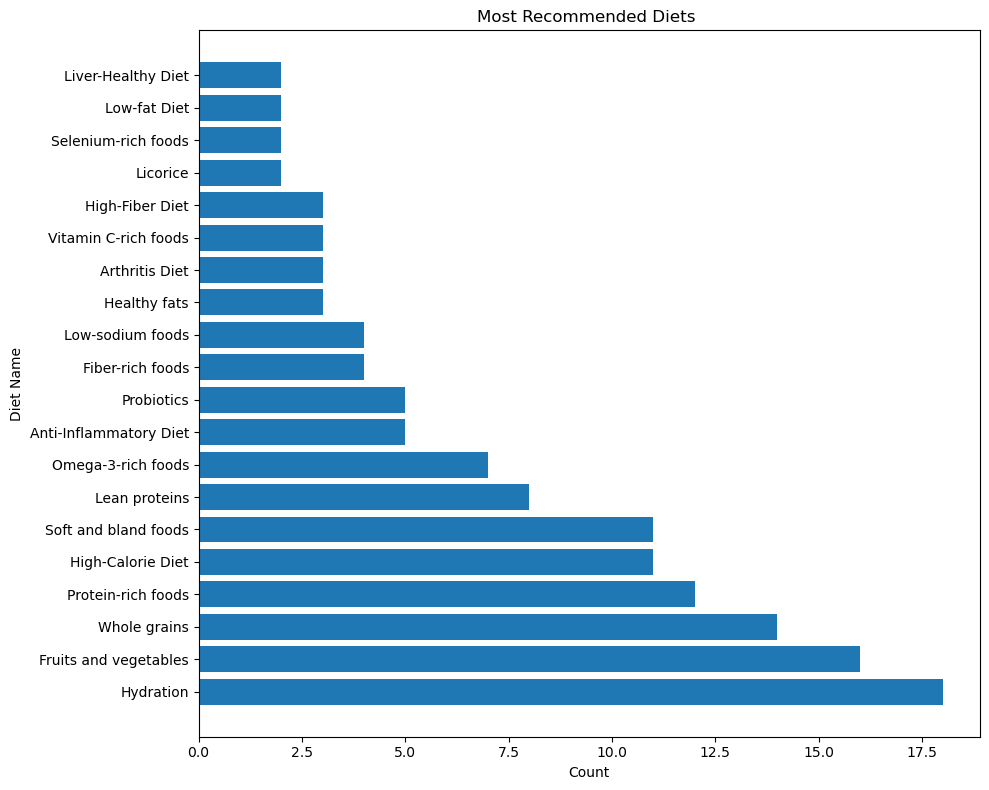

In [25]:
import ast

diet_df['Diet'] = diet_df['Diet'].apply(ast.literal_eval)
diet_exploded = diet_df.explode('Diet')
diet_count = diet_exploded['Diet'].value_counts().head(20)

plt.figure(figsize=(10, 8))
plt.barh(diet_count.index, diet_count.values)
plt.xlabel("Count")
plt.ylabel("Diet Name")
plt.title("Most Recommended Diets ")
plt.tight_layout()
plt.show()